# 🧠 Age, Gender & Ethnicity Prediction

**Multi-Head CNN using Pandas + TensorFlow approach**

---

## 📦 Import Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, Model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



2026-02-09 15:05:09.805123: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770649510.222828      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770649510.342442      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770649511.274404      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770649511.274448      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770649511.274452      55 computation_placer.cc:177] computation placer alr

## ⚙️ Configuration

In [2]:
CSV_PATH = '/kaggle/input/age-gender-and-ethnicity-face-data-csv/age_gender.csv'

IMG_SIZE = 64 
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
EPOCHS = 100
LEARNING_RATE = 1e-3

## 📂 Load and Split Data using Pandas

In [3]:
print("📖 Loading CSV...")
df = pd.read_csv(CSV_PATH)

df.head()

📖 Loading CSV...


,age,ethnicity,gender,img_name,pixels
0,1,2,0,20161219203650636.jpg.chip.jpg,129 128 128 126 127 130 133 135 139 142 145 14...
1,1,2,0,20161219222752047.jpg.chip.jpg,164 74 111 168 169 171 175 182 184 188 193 199...
2,1,2,0,20161219222832191.jpg.chip.jpg,67 70 71 70 69 67 70 79 90 103 116 132 145 155...
3,1,2,0,20161220144911423.jpg.chip.jpg,193 197 198 200 199 200 202 203 204 205 208 21...
4,1,2,0,20161220144914327.jpg.chip.jpg,202 205 209 210 209 209 210 211 212 214 218 21...


In [4]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

total_samples = len(df)
train_size = int(0.70 * total_samples)
val_size = int(0.15 * total_samples)

train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:train_size+val_size]
test_df = df.iloc[train_size+val_size:]

print("📊 Data Split:")
print(f"   Train: {len(train_df):,} samples")
print(f"   Val:   {len(val_df):,} samples")
print(f"   Test:  {len(test_df):,} samples")

📊 Data Split:
   Train: 16,593 samples
   Val:   3,555 samples
   Test:  3,557 samples


## 🖼️ Image Preprocessing Functions

In [5]:
def load_image_from_pixels(pixels_str):
    pixels = tf.strings.split(pixels_str, ' ')
    pixels = tf.strings.to_number(pixels, out_type=tf.float32)
    image = tf.reshape(pixels, [48, 48, 1])
    image = tf.image.grayscale_to_rgb(image)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    
    return image


In [6]:
def process_row(pixels_str, age, gender, ethnicity):

    image = load_image_from_pixels(pixels_str)
    
    labels = {
        "age": age,
        "gender": gender,
        "ethnicity": ethnicity
    }
    
    return image, labels



## 🔄 Create TensorFlow Datasets

In [7]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (
        train_df["pixels"].values,
        train_df["age"].values,
        train_df["gender"].values,
        train_df["ethnicity"].values
    )
)

train_ds = (
    train_ds
    .map(process_row, num_parallel_calls=AUTOTUNE)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print(f"✅ Train dataset created: {len(train_df):,} samples")

I0000 00:00:1770649534.980272      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1770649534.986252      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


✅ Train dataset created: 16,593 samples


In [8]:
val_ds = tf.data.Dataset.from_tensor_slices(
    (
        val_df["pixels"].values,
        val_df["age"].values,
        val_df["gender"].values,
        val_df["ethnicity"].values
    )
)

val_ds = (
    val_ds
    .map(process_row, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print(f"✅ Validation dataset created: {len(val_df):,} samples")

✅ Validation dataset created: 3,555 samples


In [9]:
test_ds = tf.data.Dataset.from_tensor_slices(
    (
        test_df["pixels"].values,
        test_df["age"].values,
        test_df["gender"].values,
        test_df["ethnicity"].values
    )
)

test_ds = (
    test_ds
    .map(process_row, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print(f"✅ Test dataset created: {len(test_df):,} samples")

✅ Test dataset created: 3,557 samples


## 🔍 Verify Dataset

In [10]:
batch = next(iter(train_ds))
images, labels = batch

print("\n" + "="*60)
print("BATCH VERIFICATION")
print("="*60)
print(f"Images shape: {images.shape}")
print(f"Age sample: {labels['age'][0].numpy()}")
print(f"Gender sample: {labels['gender'][0].numpy()}")
print(f"Ethnicity sample: {labels['ethnicity'][0].numpy()}")
print("="*60)


BATCH VERIFICATION
Images shape: (32, 64, 64, 3)
Age sample: 26
Gender sample: 1
Ethnicity sample: 0


## 🎨 Visualize Data

In [11]:
def visualize_batch(dataset, n=16):
    gender_map = {0: 'Male', 1: 'Female'}
    ethnicity_map = {0: 'White', 1: 'Black', 2: 'Asian', 3: 'Indian', 4: 'Others'}
    
    images, labels = next(iter(dataset))
    
    grid_size = int(np.ceil(np.sqrt(n)))
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(15, 15))
    fig.suptitle('Training Data Samples', fontsize=16, fontweight='bold')
    axes = axes.flatten()
    
    for i in range(n):
        axes[i].imshow(images[i])
        axes[i].axis('off')
        
        age = labels['age'][i].numpy()
        gender = labels['gender'][i].numpy()
        ethnicity = labels['ethnicity'][i].numpy()
        
        title = f"Age: {age}\n"
        title += f"{gender_map.get(gender, 'Unknown')}\n"
        title += f"{ethnicity_map.get(ethnicity, 'Unknown')}"
        axes[i].set_title(title, fontsize=9)
    
    for i in range(n, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()


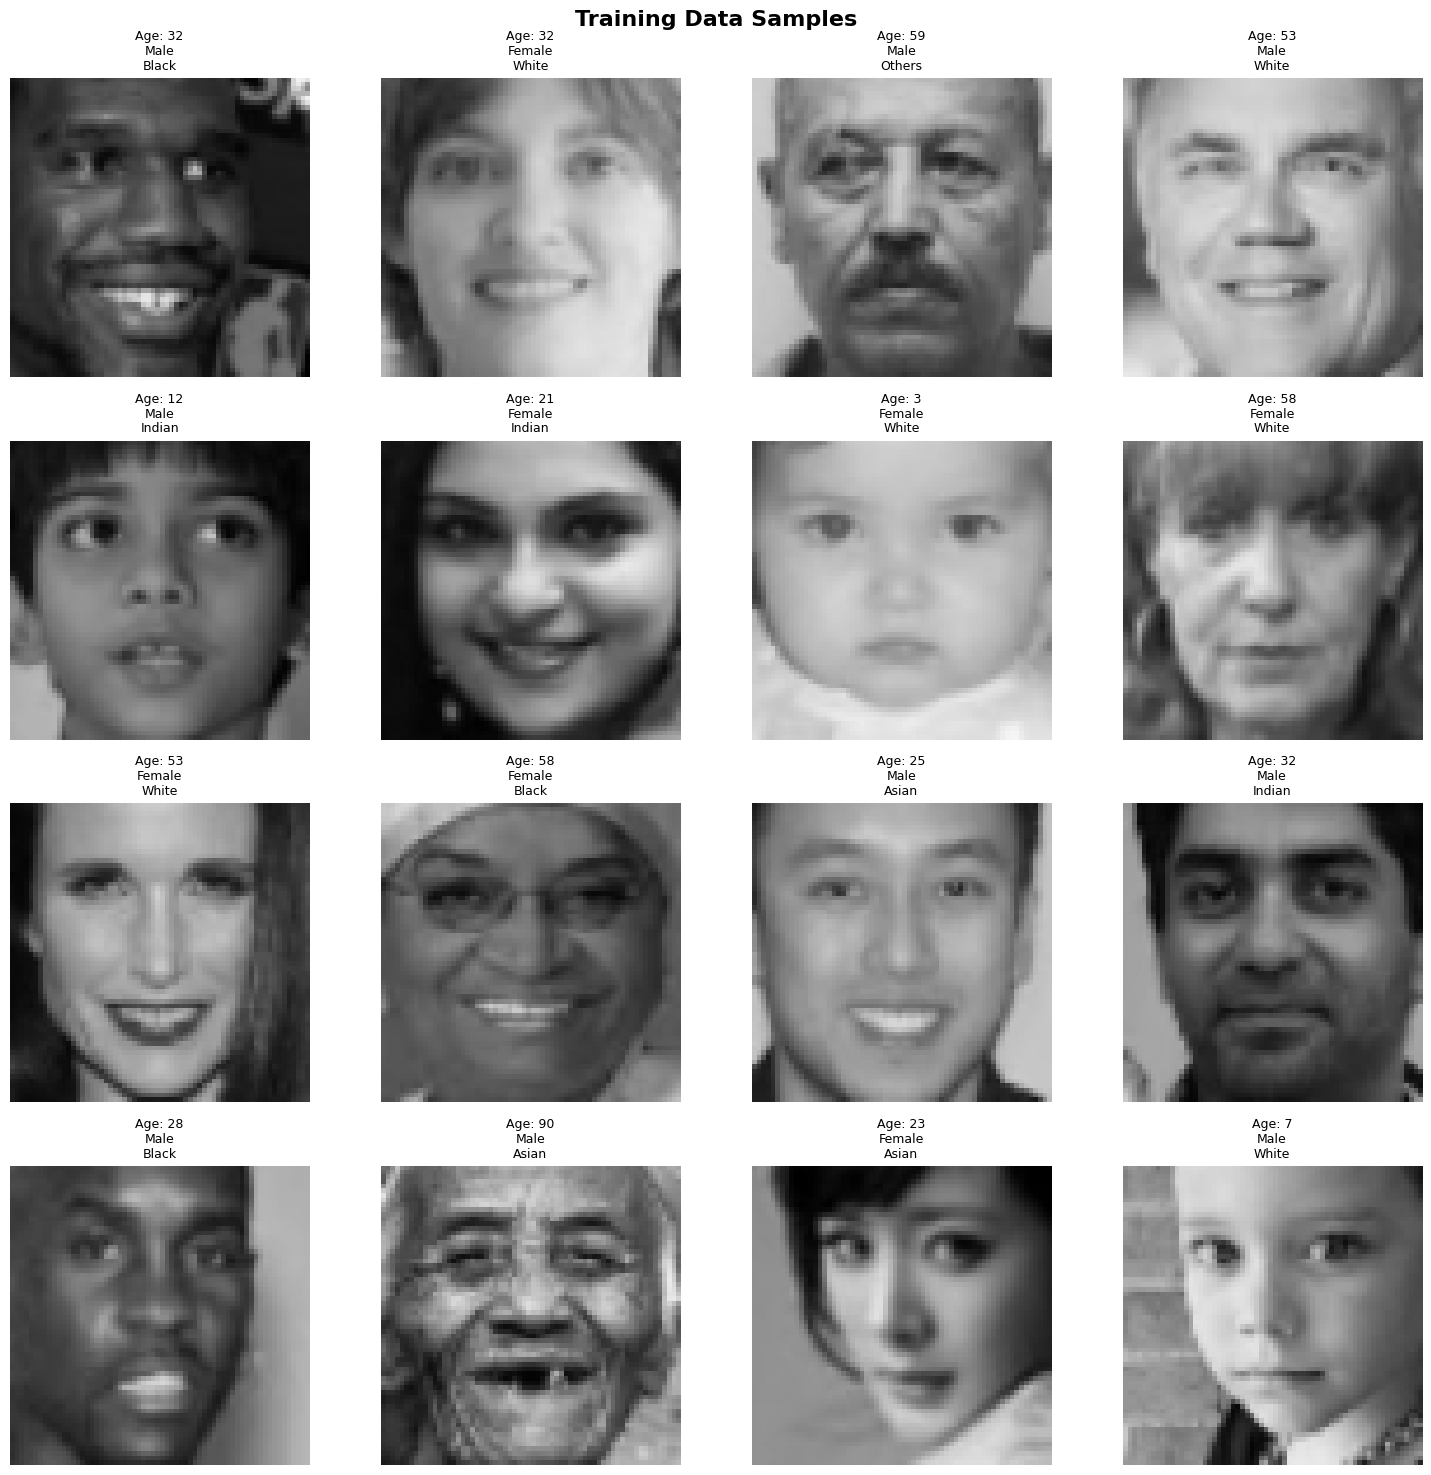

In [12]:
visualize_batch(train_ds, n=16)

## 🏗️ Build Multi-Head CNN Model

In [13]:
# inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(inputs)
# x = layers.MaxPooling2D()(x)

# x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
# x = layers.MaxPooling2D()(x)

# x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
# x = layers.MaxPooling2D()(x)

# x = layers.Flatten()(x)
# x = layers.Dense(256, activation="relu")(x)
# x = layers.Dropout(0.5)(x)

# age_output = layers.Dense(1, activation="linear", name="age")(x)

# gender_output = layers.Dense(1, activation="sigmoid", name="gender")(x)

# ethnicity_output = layers.Dense(5, activation="softmax", name="ethnicity")(x)

# model = models.Model(
#     inputs=inputs,
#     outputs=[age_output, gender_output, ethnicity_output]
# )


In [14]:
# model.summary()

## ⚙️ Compile Model

In [15]:
# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
#     loss={
#         "age": "mae",
#         "gender": "binary_crossentropy",
#         "ethnicity": "sparse_categorical_crossentropy"
#     },
#     metrics={
#         "age": ["mae"],
#         "gender": ["accuracy"],
#         "ethnicity": ["accuracy"]
#     }
# )



## 🎯 Training Callbacks

In [16]:
# early_stop = tf.keras.callbacks.EarlyStopping(
#     monitor="val_loss",
#     patience=5,
#     restore_best_weights=True,
#     verbose=1
# )

# checkpoint = tf.keras.callbacks.ModelCheckpoint(
#     "best_multihead_model.keras",
#     monitor="val_loss",
#     save_best_only=True,
#     verbose=1
# )

# lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
#     monitor="val_loss",
#     factor=0.3,
#     patience=3,
#     verbose=1
# )



## 🚀 Train Model

In [17]:
# history = model.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=EPOCHS,
#     callbacks=[early_stop, checkpoint, lr_scheduler]
# )


## 📊 Plot Training History

In [18]:
# def plot_history(history, metric):
#     plt.figure(figsize=(10, 5))
#     plt.plot(history.history[f'{metric}'], label=f'Train {metric}', linewidth=2)
#     plt.plot(history.history[f'val_{metric}'], label=f'Val {metric}', linewidth=2)
#     plt.xlabel("Epochs", fontsize=12)
#     plt.ylabel(metric, fontsize=12)
#     plt.title(f'{metric.capitalize()} over Epochs', fontsize=14, fontweight='bold')
#     plt.legend(fontsize=11)
#     plt.grid(True, alpha=0.3)
#     plt.show()


In [19]:

# plot_history(history, "loss")

# heads = ["age", "gender", "ethnicity"]
# for head in heads:
#     if head == "age":
#         plot_history(history, f"{head}_mae")
#     else:
#         plot_history(history, f"{head}_accuracy")


## 🧪 Evaluate on Test Set

In [20]:

# results = model.evaluate(test_ds, return_dict=True)

# print("\n" + "="*60)
# print("TEST SET RESULTS")
# print("="*60)
# for k, v in results.items():
#     print(f"{k}: {v:.4f}")
# print("="*60)

## 🔮 Make Predictions

In [21]:
# def visualize_predictions(images, labels, preds, n=6):

#     gender_map = {0: 'Male', 1: 'Female'}
#     ethnicity_map = {0: 'White', 1: 'Black', 2: 'Asian', 3: 'Indian', 4: 'Others'}
    
#     cols = 3  
#     rows = int(np.ceil(n / cols)) 
    
#     plt.figure(figsize=(18, rows * 3))  
    
#     for i in range(n):
#         plt.subplot(rows, cols, i+1)  
#         plt.imshow(images[i])
#         plt.axis("off")
        
#         true_age = labels['age'][i].numpy()
#         true_gender = labels['gender'][i].numpy()
#         true_ethnicity = labels['ethnicity'][i].numpy()
        
#         pred_age = preds[0][i][0]
#         pred_gender = 1 if preds[1][i][0] > 0.5 else 0
#         pred_ethnicity = np.argmax(preds[2][i])
        
#         age_error = abs(pred_age - true_age)
#         gender_correct = "✅" if pred_gender == true_gender else "❌"
#         ethnicity_correct = "✅" if pred_ethnicity == true_ethnicity else "❌"
        
#         title = f"GT: Age {true_age} | {gender_map[true_gender]} | {ethnicity_map[true_ethnicity]}\n"
#         title += f"Pred: Age {pred_age:.0f} (±{age_error:.0f}) | {gender_map[pred_gender]} {gender_correct} | {ethnicity_map[pred_ethnicity]} {ethnicity_correct}"
        
#         plt.title(title, fontsize=8)
    
#     plt.tight_layout()
#     plt.show()

In [22]:
# images, labels = next(iter(test_ds))
# preds = model.predict(images)

# visualize_predictions(images, labels, preds, n=18)

In [23]:
from tensorflow.keras.applications import VGG16 , ResNet50 ,MobileNetV2 , EfficientNetB0

In [24]:
# def bulid_multitask_model(base_model):
#     for layer in base_model.layers:
#         layer.trainable = False


#     x = base_model.output
#     x = layers.GlobalAveragePooling2D()(x)
#     x = layers.Dense(256 , activation = 'relu')(x)
#     x = layers.Dropout(0.5)(x)

#     age_output = layers.Dense(1, activation="linear", name="age")(x)

#     gender_output = layers.Dense(1, activation="sigmoid", name="gender")(x)

#     ethnicity_output = layers.Dense(5, activation="softmax", name="ethnicity")(x)
    
#     model = models.Model(inputs = base_model.input ,
#                         outputs=[age_output,gender_output,ethnicity_output] 
#                         )
#     model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
#     loss={
#         "age": "mae",
#         "gender": "binary_crossentropy",
#         "ethnicity": "sparse_categorical_crossentropy"
#     },
#     metrics={
#         "age": ["mae"],
#         "gender": ["accuracy"],
#         "ethnicity": ["accuracy"]
#     }
#     )
#     return model


def bulid_multitask_model(base_model):
    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    age_output = layers.Dense(1, activation="linear", name="age")(x)
    gender_output = layers.Dense(1, activation="sigmoid", name="gender")(x)
    ethnicity_output = layers.Dense(5, activation="softmax", name="ethnicity")(x)

    model = models.Model(
        inputs=base_model.input,
        outputs=[age_output, gender_output, ethnicity_output],
        name="vgg16_multitask"
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE,
            name="adam"   # 👈 مهم
        ),
        loss={
            "age": "mae",
            "gender": "binary_crossentropy",
            "ethnicity": "sparse_categorical_crossentropy"
        },
        metrics={
            "age": ["mae"],
            "gender": ["accuracy"],
            "ethnicity": ["accuracy"]
        }
    )
    return model


In [25]:
vgg_base = VGG16(
    weights = 'imagenet',
    include_top = False ,
    input_shape = (64,64,3)
)

vgg_model = bulid_multitask_model(vgg_base)


ResNet50_base = ResNet50(
    weights = 'imagenet',
    include_top = False ,
    input_shape = (64,64,3)
)

ResNet50_model = bulid_multitask_model(ResNet50_base)

MobileNetV2_base = MobileNetV2(
    weights = 'imagenet',
    include_top = False ,
    input_shape = (64,64,3)
)

MobileNetV2_model = bulid_multitask_model(MobileNetV2_base)

EfficientNetB0_base = EfficientNetB0(
    weights = 'imagenet',
    include_top = False ,
    input_shape = (64,64,3)
)

EfficientNetB0_model = bulid_multitask_model(EfficientNetB0_base)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/tmp/ipykernel_55/3228325112.py:18: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  MobileNetV2_base = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [26]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_multihead_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    verbose=1
)



In [27]:
from tensorflow.keras.callbacks import ModelCheckpoint


In [28]:
vgg_checkpoint = ModelCheckpoint(
    "best_vgg16.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

resnet_checkpoint = ModelCheckpoint(
    "best_resnet50.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

mobilenet_checkpoint = ModelCheckpoint(
    "best_mobilenetv2.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

efficient_checkpoint = ModelCheckpoint(
    "best_efficientnetb0.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)


In [29]:
history1 = vgg_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, vgg_checkpoint, lr_scheduler]
)


Epoch 1/100


I0000 00:00:1770649546.756098     121 service.cc:152] XLA service 0x7e6484002320 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770649546.756137     121 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1770649546.756143     121 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1770649547.487247     121 cuda_dnn.cc:529] Loaded cuDNN version 91002


 10/519 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - age_loss: 31.3050 - age_mae: 31.3050 - ethnicity_accuracy: 0.3773 - ethnicity_loss: 1.6659 - gender_accuracy: 0.4971 - gender_loss: 0.7597 - loss: 33.7306

I0000 00:00:1770649551.797963     121 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - age_loss: 16.3940 - age_mae: 16.3940 - ethnicity_accuracy: 0.3735 - ethnicity_loss: 1.8024 - gender_accuracy: 0.5825 - gender_loss: 0.8263 - loss: 19.0227
Epoch 1: val_loss improved from inf to 13.27050, saving model to best_vgg16.keras
519/519 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step - age_loss: 16.3888 - age_mae: 16.3888 - ethnicity_accuracy: 0.3736 - ethnicity_loss: 1.8020 - gender_accuracy: 0.5826 - gender_loss: 0.8261 - loss: 19.0168 - val_age_loss: 11.5093 - val_age_mae: 11.5005 - val_ethnicity_accuracy: 0.5139 - val_ethnicity_loss: 1.2437 - val_gender_accuracy: 0.7502 - val_gender_loss: 0.5308 - val_loss: 13.2705 - learning_rate: 0.0010
Epoch 2/100
517/519 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - age_loss: 11.6406 - age_mae: 11.6406 - ethnicity_accuracy: 0.5057 - ethnicity_loss: 1.2838 - gender_accuracy: 0.7039 - gender_loss: 0.5746 - loss: 13.4990
Epoch 2: val_loss improved from 13.27050 to 12.50646, saving model to best_vgg16.keras
519/519 ━━━━

In [30]:
history2 = ResNet50_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, resnet_checkpoint, lr_scheduler]
)

Epoch 1/100
519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - age_loss: 17.9803 - age_mae: 17.9803 - ethnicity_accuracy: 0.3208 - ethnicity_loss: 1.9729 - gender_accuracy: 0.5084 - gender_loss: 0.8989 - loss: 20.8521
Epoch 1: val_loss improved from inf to 17.10728, saving model to best_resnet50.keras
519/519 ━━━━━━━━━━━━━━━━━━━━ 34s 42ms/step - age_loss: 17.9764 - age_mae: 17.9764 - ethnicity_accuracy: 0.3208 - ethnicity_loss: 1.9725 - gender_accuracy: 0.5084 - gender_loss: 0.8987 - loss: 20.8477 - val_age_loss: 15.0056 - val_age_mae: 14.9793 - val_ethnicity_accuracy: 0.4273 - val_ethnicity_loss: 1.4456 - val_gender_accuracy: 0.5328 - val_gender_loss: 0.6849 - val_loss: 17.1073 - learning_rate: 0.0010
Epoch 2/100
519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - age_loss: 15.0792 - age_mae: 15.0792 - ethnicity_accuracy: 0.4204 - ethnicity_loss: 1.4834 - gender_accuracy: 0.5273 - gender_loss: 0.6938 - loss: 17.2565
Epoch 2: val_loss improved from 17.10728 to 16.91698, saving model to best_resnet50.

In [31]:
history3 = MobileNetV2_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, mobilenet_checkpoint, lr_scheduler]
)


Epoch 1/100


2026-02-09 15:30:20.748070: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-09 15:30:20.886715: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


514/519 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - age_loss: 14.7655 - age_mae: 14.7655 - ethnicity_accuracy: 0.3908 - ethnicity_loss: 1.9882 - gender_accuracy: 0.6552 - gender_loss: 0.7293 - loss: 17.4830

2026-02-09 15:30:35.948814: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-09 15:30:36.108265: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-09 15:30:36.245326: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - age_loss: 14.7450 - age_mae: 14.7450 - ethnicity_accuracy: 0.3913 - ethnicity_loss: 1.9850 - gender_accuracy: 0.6556 - gender_loss: 0.7284 - loss: 17.4583

2026-02-09 15:30:50.831411: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-09 15:30:50.977136: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-09 15:30:51.113650: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_loss improved from inf to 12.30226, saving model to best_mobilenetv2.keras
519/519 ━━━━━━━━━━━━━━━━━━━━ 47s 58ms/step - age_loss: 14.7409 - age_mae: 14.7409 - ethnicity_accuracy: 0.3914 - ethnicity_loss: 1.9843 - gender_accuracy: 0.6557 - gender_loss: 0.7282 - loss: 17.4534 - val_age_loss: 10.5181 - val_age_mae: 10.5760 - val_ethnicity_accuracy: 0.5435 - val_ethnicity_loss: 1.2086 - val_gender_accuracy: 0.7404 - val_gender_loss: 0.5215 - val_loss: 12.3023 - learning_rate: 0.0010
Epoch 2/100
514/519 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - age_loss: 11.1924 - age_mae: 11.1924 - ethnicity_accuracy: 0.5072 - ethnicity_loss: 1.2880 - gender_accuracy: 0.7407 - gender_loss: 0.5308 - loss: 13.0112
Epoch 2: val_loss improved from 12.30226 to 12.05013, saving model to best_mobilenetv2.keras
519/519 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - age_loss: 11.1917 - age_mae: 11.1917 - ethnicity_accuracy: 0.5073 - ethnicity_loss: 1.2878 - gender_accuracy: 0.7407 - gender_loss: 0.5308 - loss: 13.0102

In [32]:
history4 = EfficientNetB0_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, efficient_checkpoint, lr_scheduler]
)


Epoch 1/100


2026-02-09 15:34:23.905428: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-09 15:34:24.038905: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-09 15:34:24.350681: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-09 15:34:24.491918: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-09 15:34:25.201110: E external/local_xla/xla/stream_

518/519 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - age_loss: 16.5853 - age_mae: 16.5853 - ethnicity_accuracy: 0.3157 - ethnicity_loss: 2.1626 - gender_accuracy: 0.5064 - gender_loss: 0.9312 - loss: 19.6791

2026-02-09 15:34:42.476378: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-09 15:34:42.609917: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-09 15:34:42.916573: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-09 15:34:43.057898: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-09 15:34:43.795345: E external/local_xla/xla/stream_

519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - age_loss: 16.5835 - age_mae: 16.5834 - ethnicity_accuracy: 0.3157 - ethnicity_loss: 2.1620 - gender_accuracy: 0.5064 - gender_loss: 0.9310 - loss: 19.6765

2026-02-09 15:35:00.280740: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-09 15:35:00.414159: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-09 15:35:00.710165: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-09 15:35:00.851682: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-09 15:35:01.537781: E external/local_xla/xla/stream_


Epoch 1: val_loss improved from inf to 17.50568, saving model to best_efficientnetb0.keras
519/519 ━━━━━━━━━━━━━━━━━━━━ 57s 65ms/step - age_loss: 16.5816 - age_mae: 16.5816 - ethnicity_accuracy: 0.3158 - ethnicity_loss: 2.1614 - gender_accuracy: 0.5063 - gender_loss: 0.9308 - loss: 19.6738 - val_age_loss: 15.3975 - val_age_mae: 15.3595 - val_ethnicity_accuracy: 0.4273 - val_ethnicity_loss: 1.4551 - val_gender_accuracy: 0.5111 - val_gender_loss: 0.6929 - val_loss: 17.5057 - learning_rate: 0.0010
Epoch 2/100
518/519 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - age_loss: 15.3761 - age_mae: 15.3761 - ethnicity_accuracy: 0.4178 - ethnicity_loss: 1.4887 - gender_accuracy: 0.5049 - gender_loss: 0.7062 - loss: 17.5710
Epoch 2: val_loss improved from 17.50568 to 17.48599, saving model to best_efficientnetb0.keras
519/519 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - age_loss: 15.3763 - age_mae: 15.3763 - ethnicity_accuracy: 0.4178 - ethnicity_loss: 1.4887 - gender_accuracy: 0.5049 - gender_loss: 0.7062 - loss: 1

In [33]:
print("VGG16 best val loss:", min(history1.history["val_loss"]))
print("ResNet50 best val loss:", min(history2.history["val_loss"]))
print("MobileNetV2 best val loss:", min(history3.history["val_loss"]))
print("EfficientNetB0 best val loss:", min(history4.history["val_loss"]))


VGG16 best val loss: 10.857254981994629
ResNet50 best val loss: 14.161540031433105
MobileNetV2 best val loss: 11.511567115783691
EfficientNetB0 best val loss: 17.322214126586914


In [34]:
models = {
    "vgg16": (vgg_model, history1),
    "resnet50": (ResNet50_model, history2),
    "mobilenetv2": (MobileNetV2_model, history3),
    "efficientnetb0": (EfficientNetB0_model, history4),
}

best_name, (best_model, _) = min(
    models.items(),
    key=lambda x: min(x[1][1].history["val_loss"])
)

best_model.save(f"best_overall_{best_name}.keras")
print("Best model saved:", best_name)


Best model saved: vgg16


In [35]:
from tensorflow.keras.models import load_model

best_model = load_model("best_efficientnetb0.keras")


In [36]:
globals().keys()

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', '_', '__', '___', '_i', '_ii', '_iii', '_i1', 'tf', 'layers', 'models', 'Model', 'pd', 'np', 'plt', '_i2', 'CSV_PATH', 'IMG_SIZE', 'BATCH_SIZE', 'AUTOTUNE', 'EPOCHS', 'LEARNING_RATE', '_i3', 'df', '_3', '_i4', 'total_samples', 'train_size', 'val_size', 'train_df', 'val_df', 'test_df', '_i5', 'load_image_from_pixels', '_i6', 'process_row', '_i7', 'train_ds', '_i8', 'val_ds', '_i9', 'test_ds', '_i10', 'batch', 'images', 'labels', '_i11', 'visualize_batch', '_i12', '_i13', '_i14', '_i15', '_i16', '_i17', '_i18', '_i19', '_i20', '_i21', '_i22', '_i23', 'VGG16', 'ResNet50', 'MobileNetV2', 'EfficientNetB0', '_i24', 'bulid_multitask_model', '_i25', 'vgg_base', 'vgg_model', 'ResNet50_base', 'ResNet50_model', 'MobileNetV2_base', 'MobileNetV2_model', 'EfficientNetB0_base', 'EfficientNetB0_model', '_i26', 'early_stop', 'checkpoi

In [37]:
import os
os.listdir(".")

['best_vgg16.keras',
 'best_mobilenetv2.keras',
 '.virtual_documents',
 'best_overall_vgg16.keras',
 'best_efficientnetb0.keras',
 'best_resnet50.keras']

In [38]:
# model.save('final_age_gender_ethnicity_model.keras')
